# Benchmark analysis

Use this notebook to evaluate fluorescence image predictions for a selected organelle.

- Choose the organelle to analyze.
- Specify the directory containing the image patches.
- Choose the number of patches to load.
- The notebook can analyze either:
    - DDPM and DM4ISL predictions generated by the TRAIN and INFERENCE notebooks, or
    - the benchmark patches downloaded from BIA, which also include U-Net and GAN predictions.
- When using the BIA benchmark data, all four methods (U-Net, GAN, DM, and DM4ISL) are evaluated.

In [1]:
## ------------------------------------------------------------------
## Configuration
## ------------------------------------------------------------------

# Choose one of:
# Nuclear_envelope, Nucleoli, DNA, Actin_filaments, Mitochondria, Microtubules
organelle = 'Nuclear_envelope'

## ------------------------------------------------------------------
## Input
## ------------------------------------------------------------------

# Directory containing the patches to analyze.
# This can be either:
#   - patches generated by the TRAIN and INFERENCE notebooks, or
#   - the benchmark patches downloaded from BIA.
# patches_path = "/your/path/to/test_patches"
patches_path = "/groups/assafza_group/assafza/Orit/DM4ISL/DM4ISL_BIA_DATA/bia_submission"

# The organelle subdirectory under patches_path is expected to have
# the same name as the selected organelle.

## ------------------------------------------------------------------
## Analysis settings
## ------------------------------------------------------------------

# Number of patches to load.
# Use 128 to reproduce the paper results, or a smaller number (e.g. 3 or 4) for a quick test.
Nimgs = 128

In [2]:
import skimage
from skimage.metrics import hausdorff_distance
from skimage.feature import hog

import scipy
from scipy import ndimage
from scipy.spatial.distance import jensenshannon
from scipy.ndimage import distance_transform_edt, label, binary_fill_holes
import scipy.stats as stats


import torch
from torch.optim import AdamW
from torch.autograd import Function
from torch import einsum
from torch.fft import fft2, ifft2
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.utils import data
import torch.nn.functional as F
from torchvision.models import vgg16
import torchvision.transforms as torch_transforms
from torchvision import utils as vutils
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import tifffile
import cv2 
import random
import pandas as pd

from src.DisplayFunctions import display_images, volumetric2sequence, display_images_grid
from src.LoadSaveFunctions import load_patches, LoadModel, save_patches
from src.MetricsFunctions import calc_metrics

from src.Params import SegmentationParams, uncertaintymap_parameters
from src.ProcessingFunctions import segmentation_pipeline_per_patch, watershed_on_seg3D

# Number of decimal places used when rounding the benchmark metrics
rn = 4

/home/kliper/.conda/envs/dm4isl_test/lib/python3.9/site-packages/monai/utils/module.py:396: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  pkg = __import__(module)  # top level module


In [3]:
# initialize GPU and organelle-specific segmentation parameters
device = torch.device("cuda") 
organelle_seg_params = SegmentationParams(organelle)

In [4]:
### load data        
BF_images      = load_patches(patches_path, organelle, 'BF', Nimgs)      # (128, 16, 64, 64) 0-1
FL_images      = load_patches(patches_path, organelle, 'GT', Nimgs)      # (128, 16, 64, 64) 0-1
Unet_images    = load_patches(patches_path, organelle, 'Unet', Nimgs)    # (128, 16, 64, 64) 0-1
GAN_images     = load_patches(patches_path, organelle, 'GAN', Nimgs)     # (128, 16, 64, 64) 0-1
DDPM_images    = load_patches(patches_path, organelle, 'DDPM', Nimgs)    # (128, 16, 64, 64) 0-1
DDPMavg_images = load_patches(patches_path, organelle, 'DDPMavg', Nimgs) # (128, 16, 64, 64) 0-1
DDPMstd_images = load_patches(patches_path, organelle, 'DDPMstd', Nimgs) # (128, 16, 64, 64) 0-1

In [5]:
### calculate metrics
Unet_pccs, Unet_mses, Unet_msssims, Unet_jsds, Unet_mis, Unet_ious , Unet_f1s, Unet_centroid_errors,  Unet_mindist_errors,  Unet_area_errors, Unet_hds                                   = calc_metrics(FL_images, Unet_images, organelle_seg_params)
GAN_pccs, GAN_mses, GAN_msssims, GAN_jsds, GAN_mis, GAN_ious , GAN_f1s, GAN_centroid_errors,  GAN_mindist_errors,  GAN_area_errors, GAN_hds                                              = calc_metrics(FL_images, GAN_images, organelle_seg_params)
DDPM_pccs, DDPM_mses, DDPM_msssims, DDPM_jsds, DDPM_mis, DDPM_ious , DDPM_f1s, DDPM_centroid_errors,  DDPM_mindist_errors,  DDPM_area_errors, DDPM_hds                                   = calc_metrics(FL_images, DDPM_images, organelle_seg_params)
DDPMavg_pccs, DDPMavg_mses, DDPMavg_msssims, DDPMavg_jsds, DDPMavg_mis, DDPMavg_ious , DDPMavg_f1s, DDPMavg_centroid_errors,  DDPMavg_mindist_errors,  DDPMavg_area_errors, DDPMavg_hds  = calc_metrics(FL_images, DDPMavg_images, organelle_seg_params)

Unet_results    = np.array([Unet_pccs, Unet_mses, Unet_msssims, Unet_jsds, Unet_mis, Unet_ious , Unet_f1s, Unet_centroid_errors,  Unet_mindist_errors,  Unet_area_errors, Unet_hds] )
GAN_results     = np.array([GAN_pccs, GAN_mses, GAN_msssims, GAN_jsds, GAN_mis, GAN_ious , GAN_f1s, GAN_centroid_errors,  GAN_mindist_errors,  GAN_area_errors, GAN_hds] )
DDPM_results    = np.array([DDPM_pccs, DDPM_mses, DDPM_msssims, DDPM_jsds, DDPM_mis, DDPM_ious , DDPM_f1s, DDPM_centroid_errors,  DDPM_mindist_errors,  DDPM_area_errors, DDPM_hds] )
DDPMavg_results = np.array([DDPMavg_pccs, DDPMavg_mses, DDPMavg_msssims, DDPMavg_jsds, DDPMavg_mis, DDPMavg_ious , DDPMavg_f1s, DDPMavg_centroid_errors,  DDPMavg_mindist_errors,  DDPMavg_area_errors, DDPMavg_hds] )

### display metrics
model_names = ['UNet', 'GAN', 'DM', 'DM4ISL']

metrics_names = [
    'PCC', 'MSE', 'MS-SSIM', 'JSD', 'MI',
    'IoU', 'f1', 'Centroid', 'Min distance', 'Area', 'HD'
]

metrics_sign = [
     1, -1,  1, -1,  1,
     1,  1, -1, -1, -1, -1
]

models_metrics = np.array([
    Unet_results,
    GAN_results,
    DDPM_results,
    DDPMavg_results
])  # (4, 11, Nimgs)

models_metrics_df = pd.DataFrame(
    models_metrics.mean(axis=2).T,
    columns=model_names,
    index=metrics_names
).round(decimals=3)

print(models_metrics_df)

# models_metrics_df.to_csv(organelle + " results.csv", index=False)

               UNet    GAN     DM  DM4ISL
PCC           0.876  0.878  0.861   0.889
MSE           0.007  0.007  0.007   0.005
MS-SSIM       0.877  0.880  0.881   0.894
JSD           0.155  0.159  0.156   0.139
MI            1.068  1.085  1.028   1.101
IoU           0.371  0.381  0.336   0.379
f1            0.204  0.202  0.177   0.218
Centroid      0.318  0.328  0.345   0.328
Min distance  0.800  0.840  0.812   0.698
Area          3.354  3.596  3.278   3.225
HD            0.971  1.022  1.023   0.984


In [6]:
###creating uncertainty map 

std_th = uncertaintymap_parameters(organelle)

ids_i =         0 
ids_f = ids_i + Nimgs 


print('mean std of DDPMstd_images: ', DDPMstd_images.mean(), DDPMstd_images.std())
print ( 'std_th percentile: ', len(DDPMstd_images[DDPMstd_images<std_th]) / len(DDPMstd_images.flatten()) )

uncertainty_maps = []
uncertainty_maps_sum = []
std_ddpm_masks = np.where(DDPMstd_images > std_th, DDPMstd_images, 0)   # 0.02  # (16, 64, 64)
for i in range(DDPMstd_images.shape[0]):
    otsu_std_th, uncertainty_map = segmentation_pipeline_per_patch(std_ddpm_masks[i] , filter_type=organelle_seg_params.filter_type, k1=organelle_seg_params.k1, k2=organelle_seg_params.k2,    
        k3=organelle_seg_params.k3, filter_kernel=organelle_seg_params.filter_kernel, sigma=organelle_seg_params.sigma, organelle_th=organelle_seg_params.organelle_th, 
        do_erode_dilate=organelle_seg_params.do_erode_dilate, do_remove_small_objects=organelle_seg_params.do_remove_small_objects, do_fill_holes=organelle_seg_params.do_fill_holes, 
        do_fill_holes_boarders=organelle_seg_params.do_fill_holes_boarders)  
    uncertainty_maps.append(uncertainty_map)
    uncertainty_maps_sum.append(uncertainty_maps[i].sum()/255) # the maps are [0,255]
uncertainty_maps = np.array(uncertainty_maps)
uncertainty_maps_sum = np.array(uncertainty_maps_sum)

nonzero_th = 64*64*16*0.01 # 1% of the patch = 655 pixels 
uncertainty_maps_zero = len(np.where(uncertainty_maps_sum <= nonzero_th)[0])


mean std of DDPMstd_images:  0.0130523285 0.009505783
std_th percentile:  0.9923030138015747


In [7]:
### Manual error annotations and uncertainty-map evaluation
###
### Unet_error       - Manually identified substantial error in the U-Net prediction.
### Dmavg_error      - Manually identified substantial error in the DM4ISL prediction.
### UncMap_TP        - Manually identified DM4ISL error correctly flagged by the uncertainty map.
### UncMap_FP        - Region flagged by the uncertainty map but not confirmed as a substantial DM4ISL error by manual inspection.
### UncMap_FN        - Manually identified DM4ISL error missed by the uncertainty map.
### UncMap_recovered - Substantial DM4ISL error overlooked during the initial manual inspection and recovered through uncertainty-guided review.
### UncMap_ood       - Region flagged by the uncertainty map, overlooked during the initial manual inspection, and subsequently attributed to abnormal cell morphology.
###
### Visualization:
### - Green rectangles on U-Net and DM4ISL predictions indicate manually identified errors.
### - Green rectangles on uncertainty maps indicate TP or recovered errors.
### - Red rectangles on uncertainty maps indicate FP, FN, or OOD cases.
### - Recovered errors are shown with a red rectangle on the DM4ISL prediction and a green rectangle on the corresponding uncertainty map.

if organelle == 'DNA':
    Unet_error = [1, 2, 3, 4, 6, 8, 10, 13, 14, 15, 16, 18, 22, 23, 25, 28, 29, 30, 32, 35, 37, 43, 46, 47, 48, 52, 54, 70, 71, 74, 76, 78, 80, 82, 85, 87, 88, 89, 91, 92, 94, 114, 116, 121]
    Dmavg_error = [4, 6, 10, 13, 14, 25, 26, 28, 32, 34, 36, 38, 41, 43, 46, 51, 52, 54, 58, 59, 67, 104, 112, 113]
    UncMap_recovered = [63]
    UncMap_TP = [4, 6, 10, 13, 14, 25, 26, 28, 32, 34, 36, 38, 41, 46, 51, 52, 54, 58, 59, 67, 104, 112, 113]
    UncMap_FP = []
    UncMap_FN = [64]
    UncMap_ood = [16, 30, 31, 33, 42, 50, 57, 68, 69, 71, 73, 75, 76, 77, 86, 90, 92, 93, 94, 96, 103, 106, 110, 114, 116, 121]
if organelle == 'Nuclear_envelope':
    Unet_error = [1, 2, 23, 25, 59, 74, 87, 92, 101]
    Dmavg_error = [23, 25, 74, 87, 92]
    UncMap_recovered = [3, 14, 16, 34, 59, 101]
    UncMap_TP = [23, 25, 74, 87, 92]
    UncMap_FP = []
    UncMap_FN = []
    UncMap_ood = []
if organelle == 'Nucleoli':
    Unet_error = [0, 7, 12, 16, 24, 43, 46, 48, 52, 53, 55, 57, 63, 91, 95, 101, 105, 119]
    Dmavg_error = [4, 9, 12, 27, 95, 119]
    UncMap_recovered = [45, 61, 88]
    UncMap_TP = [9, 27, 95, 119]
    UncMap_FP = [10, 39]
    UncMap_FN = [4]
    UncMap_ood = []
if organelle == 'Actin_filaments':
    Unet_error = [0, 2, 5, 10, 15, 20, 32, 35, 38, 46, 47, 50, 58, 87, 98, 116, 121]
    Dmavg_error = [5, 15, 20, 33, 35, 38, 46, 47, 50, 58, 87]
    UncMap_recovered = [0, 3, 31, 49, 51, 86]
    UncMap_TP = [5, 15, 20, 33, 35, 38, 46, 47, 50, 58, 87]
    UncMap_FP = []
    UncMap_FN = []
    UncMap_ood = []
if organelle == 'Microtubules':
    Unet_error = [0, 23, 26, 32, 44, 48, 53, 60, 63, 66, 76, 79, 88, 95, 98, 100, 103, 111, 115, 116, 117, 120, 121, 124, 125]
    Dmavg_error = [0, 20, 23, 48, 53, 66, 79, 100, 111, 115, 117, 120]
    UncMap_recovered = []
    UncMap_TP = [0, 20, 23, 53, 79, 100, 111, 115, 117, 120]
    UncMap_FP = []
    UncMap_FN = [48, 66]
    UncMap_ood = []


0
Real FL


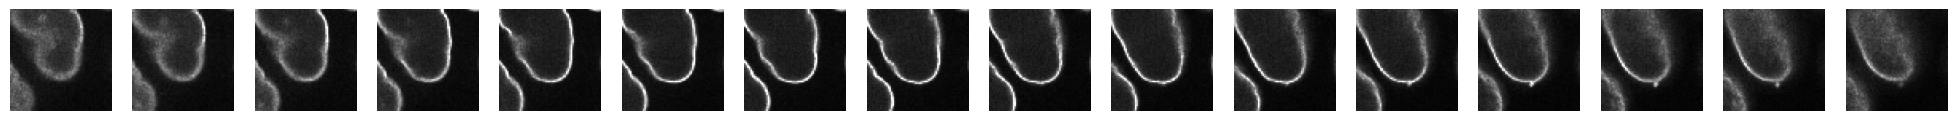

U-Net


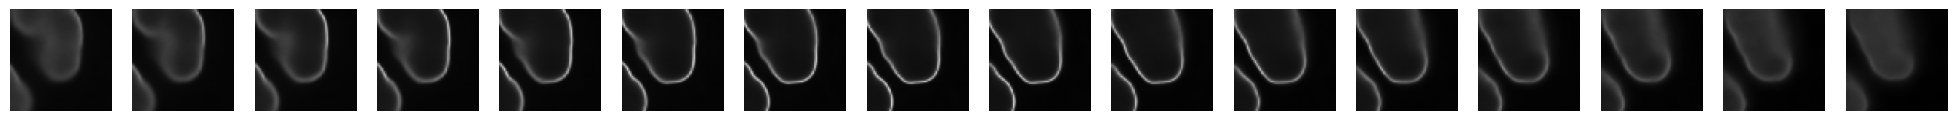

DM4ISL


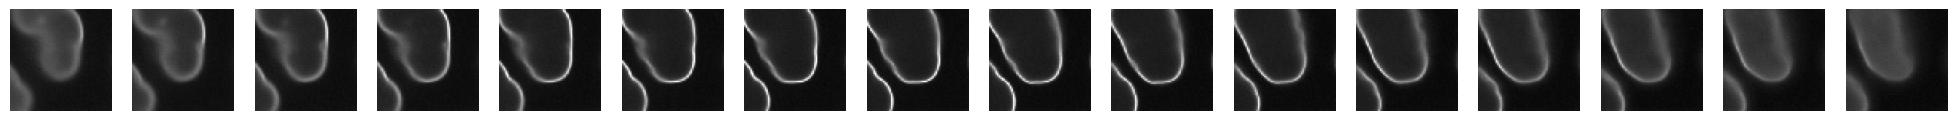

Uncertainty map sum 0.0


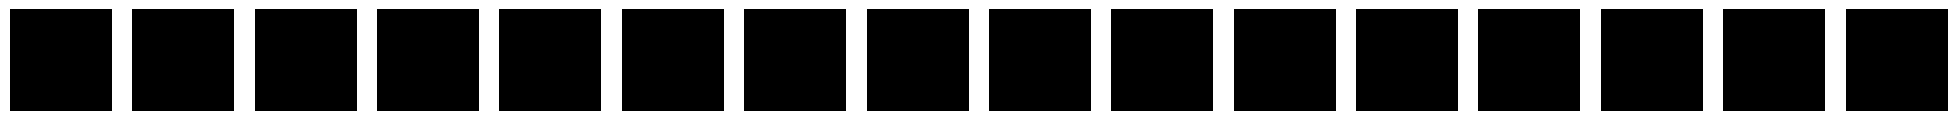


1
Real FL


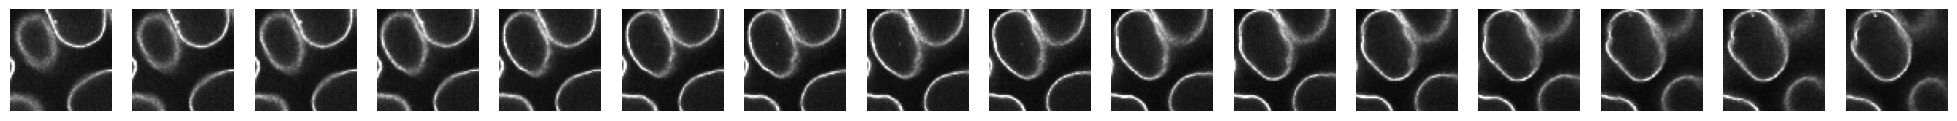

U-Net


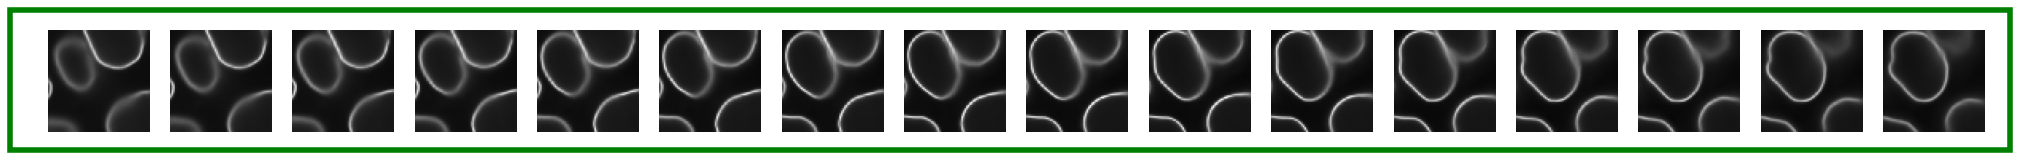

DM4ISL


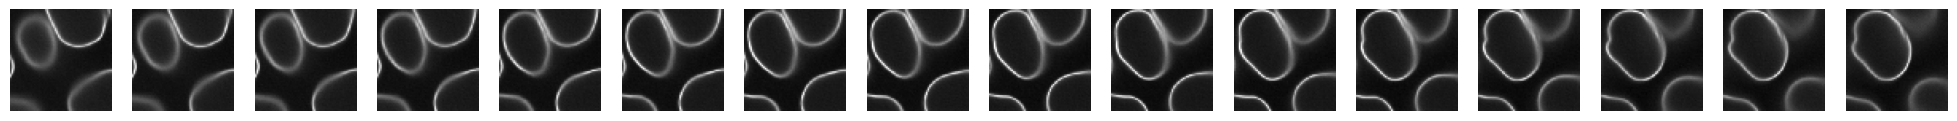

Uncertainty map sum 0.0


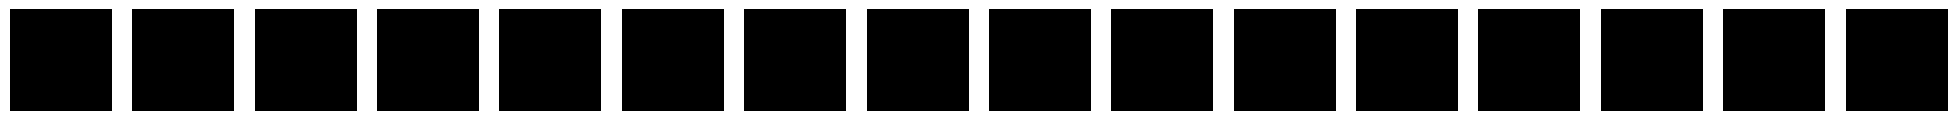


2
Real FL


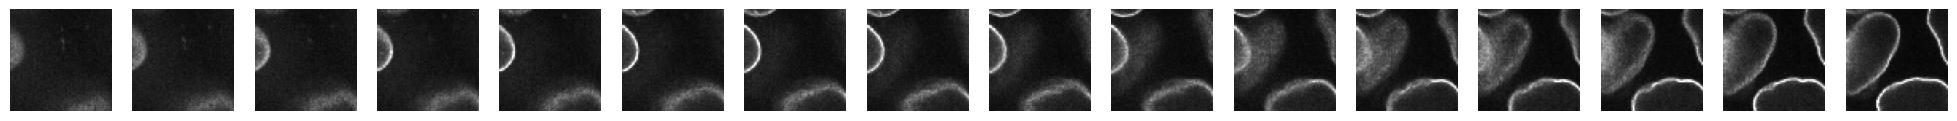

U-Net


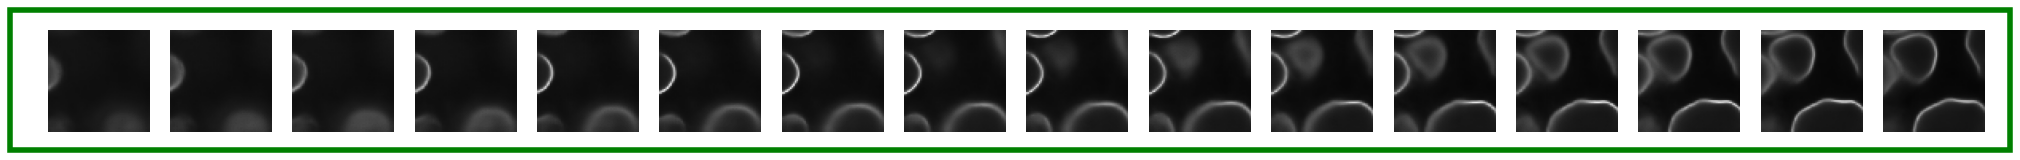

DM4ISL


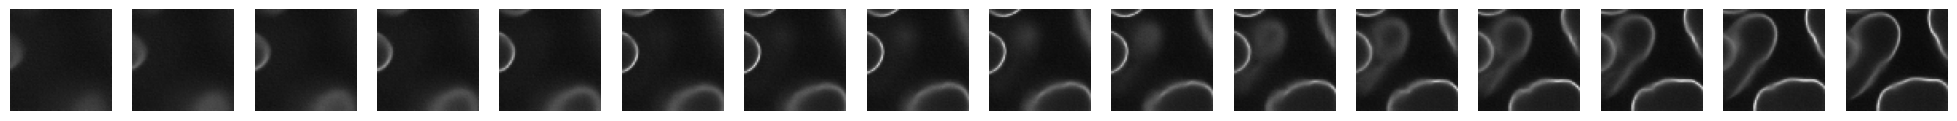

Uncertainty map sum 120.0


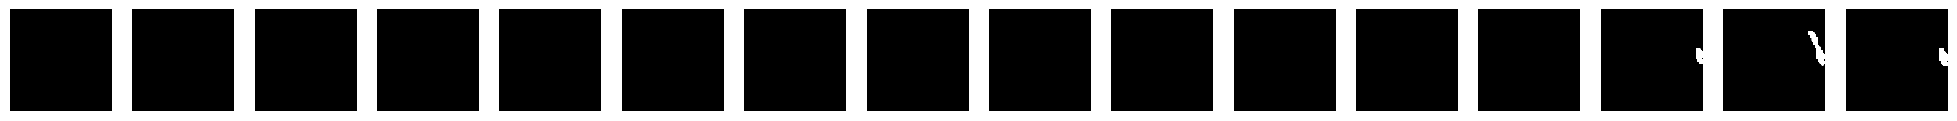


3
Real FL


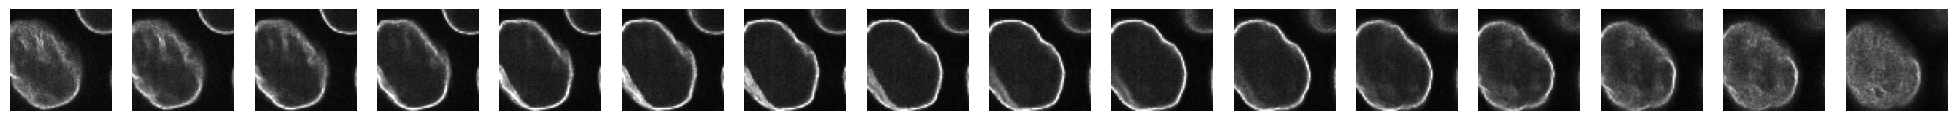

U-Net


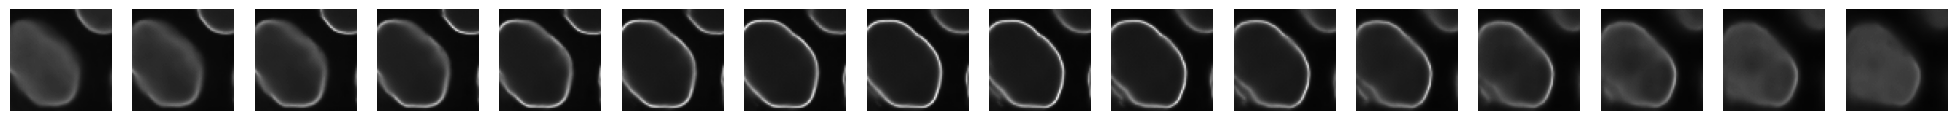

DM4ISL


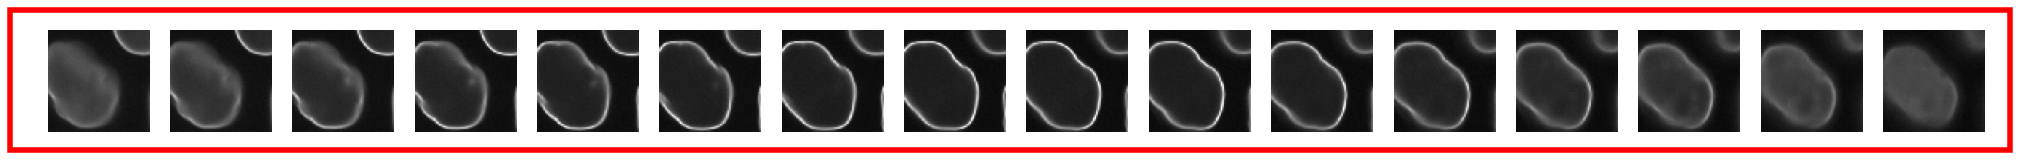

Uncertainty map sum 807.0


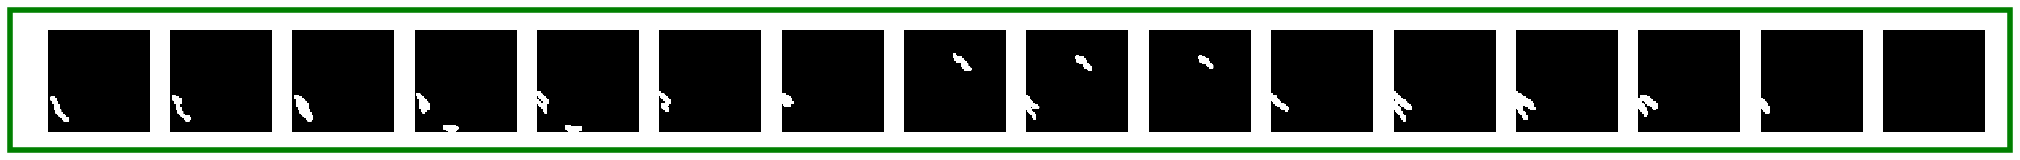

In [8]:
# Number of samples to visualize
Nimgs_display = min(Nimgs, 4)

for id in range(Nimgs_display):
# for id in range(0,Nimgs): # FL_images.shape[0]
    print('')
    print(id)
    print('Real FL')
    display_images(    FL_images[id] , 1,FL_images[0].shape[0], range(FL_images[0].shape[0]), show_labels='False', rect='none', vmin=0, vmax=1)
    print('U-Net')
    if id in Unet_error:
         display_images(    Unet_images[id] , 1,FL_images[0].shape[0], range(FL_images[0].shape[0]), show_labels='False', rect='green', vmin=0, vmax=1)
    else: 
         display_images(    Unet_images[id] , 1,FL_images[0].shape[0], range(FL_images[0].shape[0]), show_labels='False', rect='none', vmin=0, vmax=1)
    print('DM4ISL')
    if id in Dmavg_error:
        display_images(    DDPMavg_images[id] , 1,FL_images[0].shape[0], range(FL_images[0].shape[0]), show_labels='False', rect='green', vmin=0, vmax=1)
    elif id in UncMap_recovered:
        display_images(    DDPMavg_images[id] , 1,FL_images[0].shape[0], range(FL_images[0].shape[0]), show_labels='False', rect='red', vmin=0, vmax=1)
    else:
        display_images(    DDPMavg_images[id] , 1,FL_images[0].shape[0], range(FL_images[0].shape[0]), show_labels='False', rect='none', vmin=0, vmax=1)
    print('Uncertainty map sum' , uncertainty_maps_sum[id])
    if (id in UncMap_TP) or (id in UncMap_recovered):
        display_images(    uncertainty_maps[id] , 1,FL_images[0].shape[0], range(FL_images[0].shape[0]), show_labels='False', rect='green', vmin=0, vmax=1)
    elif (id in UncMap_FN) or (id in UncMap_FP) or (id in UncMap_ood):
        display_images(    uncertainty_maps[id] , 1,FL_images[0].shape[0], range(FL_images[0].shape[0]), show_labels='False', rect='red', vmin=0, vmax=1)
    else:
        display_images(    uncertainty_maps[id] , 1,FL_images[0].shape[0], range(FL_images[0].shape[0]), show_labels='False', rect='none', vmin=0, vmax=1)
